# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 8.9 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
#load the image file
images=np.load('/content/drive/MyDrive/project/images.npy')
#load the label file of the dataset
labels=pd.read_csv('/content/drive/MyDrive/project/labels.csv')

In [7]:
print(images.shape)

(4125, 200, 200, 3)


There are 4125RGB images each image  of size 200 * 200 pixel

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [8]:
def plot_images(images,labels):
    num_classes=2
    categories = {
        0: 'Without Helmet',
        1: 'With Helmet'
    }
    keys=dict(labels['label'])
    #defining number of columns
    rows=3
    cols=4
    #defining figure
    fig=plt.figure(figsize=(10,8))
    for i in range(cols):
      for j in range(rows):
         random_index=random.randint(0,len(images)-1)        #generating random indices from the data and plotting the images
         ax=fig.add_subplot(rows,cols,i*rows+j+1)
         ax.imshow(images[random_index])
         ax.set_title(categories[keys[random_index]])
         ax.axis('off')
    plt.show()      #plotting images
    plt.tight_layout()


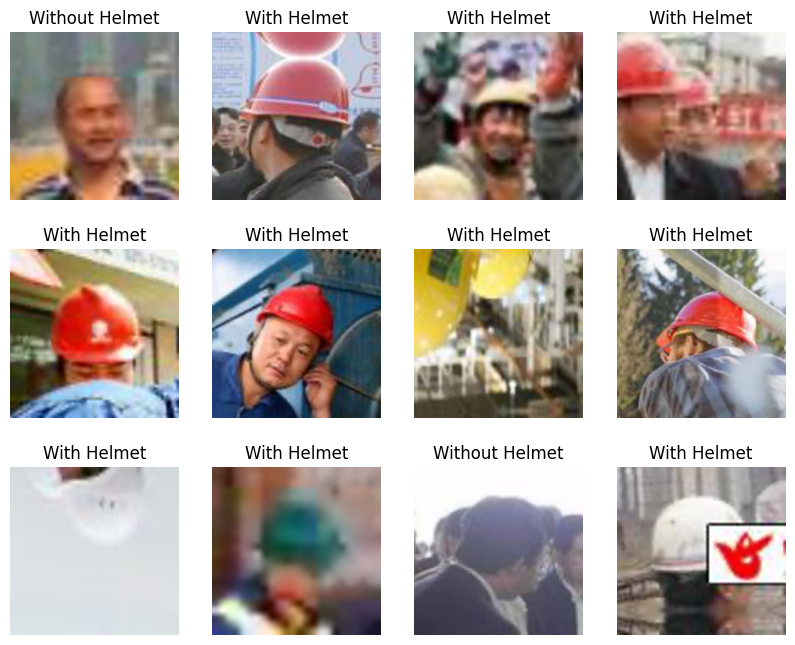

<Figure size 640x480 with 0 Axes>

In [9]:
plot_images(images,labels)

Most images shown above belong to "With helmet" category showing classs imbalance.

In [10]:
#checking null values
print(labels.isnull().sum())

label    0
dtype: int64


There is no missing value in labels dataset

In [11]:
print(images.min())
print(images.max())

0
255


Pixel values range from 0 to 255 pixels,there is a need of normalization

## Checking for class imbalance


In [12]:
print(labels['label'].value_counts())

label
1    3161
0     964
Name: count, dtype: int64


The dataset is clearly imabalanced with the images being classified as " with helmet" more than "without helmet"

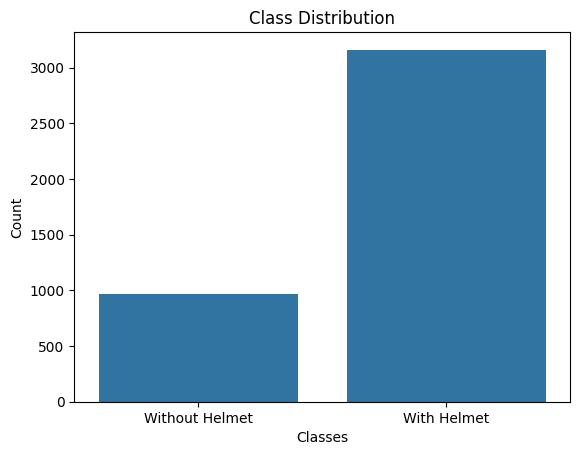

In [13]:
#plotting class imbalance using count plot
sns.countplot(x='label', data=labels)

plt.xticks([0,1], ['Without Helmet', 'With Helmet'])

plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.show()

# **Data Preprocessing**

### Splitting the dataset



In [14]:
X=images
y=labels['label']

In [15]:
#splitting the dataset into train,validation and test dataset
X_train,X_temp,y_train,y_temp=train_test_split(
    X,
    y,test_size=0.3,
    random_state=42,
    stratify=y)

#validation and test set split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

### Data Normalization

In [16]:
#normalizing the  image pixels
X_train=X_train.astype('float32')/255.0
X_val=X_val.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [17]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [18]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [19]:
model=Sequential()
#adding first conv layer of 64 filters and kernel size 3*3 pixel
model.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
#adding max pooling layer to reduce the size of the output of the first conv layer
model.add(MaxPooling2D((2,2),padding='same'))

model.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(MaxPooling2D((2,2),padding='same'))
model.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(MaxPooling2D((2,2),padding='same'))

#flattening the output of the cov layer after max pooling to make it ready forthe dense connections
model.add(Flatten())

#adding a fully connected layer with 100 neurons
model.add(Dense(100,activation='relu'))
#adding the output layer
model.add(Dense(1,activation='sigmoid'))

#compiling the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#generating the model summary
model.summary()




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,849 (15.55 MB)

 Trainable params: 4,075,849 (15.55 MB)

 Non-trainable params: 0 (0.00 B)

There are approximately 4.07 million trainable parameters

### Visualizing the predictions

In [20]:
#fitting the model on the training data
history_1=model.fit(X_train,y_train,epochs=15,batch_size=64,shuffle=True,validation_data=(X_val,y_val),verbose=2)

Epoch 1/15
46/46 - 14s - 302ms/step - accuracy: 0.7984 - loss: 0.4036 - val_accuracy: 0.9079 - val_loss: 0.2715
Epoch 2/15
46/46 - 5s - 118ms/step - accuracy: 0.9065 - loss: 0.2368 - val_accuracy: 0.9144 - val_loss: 0.2331
Epoch 3/15
46/46 - 6s - 120ms/step - accuracy: 0.9217 - loss: 0.1842 - val_accuracy: 0.9128 - val_loss: 0.2235
Epoch 4/15
46/46 - 10s - 222ms/step - accuracy: 0.9383 - loss: 0.1555 - val_accuracy: 0.9273 - val_loss: 0.2124
Epoch 5/15
46/46 - 6s - 121ms/step - accuracy: 0.9418 - loss: 0.1490 - val_accuracy: 0.9160 - val_loss: 0.2376
Epoch 6/15
46/46 - 6s - 123ms/step - accuracy: 0.9529 - loss: 0.1255 - val_accuracy: 0.8805 - val_loss: 0.5013
Epoch 7/15
46/46 - 6s - 123ms/step - accuracy: 0.9439 - loss: 0.1399 - val_accuracy: 0.9031 - val_loss: 0.2898
Epoch 8/15
46/46 - 5s - 118ms/step - accuracy: 0.9539 - loss: 0.1251 - val_accuracy: 0.9160 - val_loss: 0.2999
Epoch 9/15
46/46 - 5s - 117ms/step - accuracy: 0.9612 - loss: 0.1111 - val_accuracy: 0.9257 - val_loss: 0.2492

MODEL EVALUATION

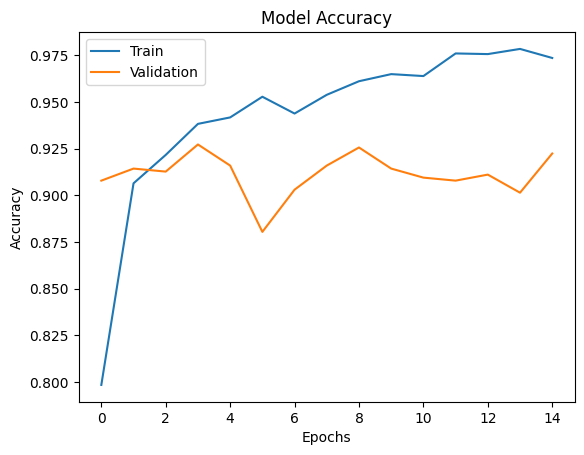

In [21]:
#plotting accuracy of training and validation set
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

The model shows high accuracy on both training and validation dataset with a slight overfitting

In [22]:
#checking the performance on the training data
cnn_train_perf = model_performance_classification(
    model,
    X_train,
    y_train
)

print("Training Performance")
print(cnn_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
Training Performance
   Accuracy    Recall  Precision  F1 Score
0  0.981988  0.981988   0.981988  0.981988


In [23]:
#checking the performance on the validation data
cnn_val_perf = model_performance_classification(
    model,
    X_val,
    y_val
)

print("Validation Performance")
print(cnn_val_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Validation Performance
   Accuracy    Recall  Precision  F1 Score
0  0.922456  0.922456   0.922456  0.922456


The model is giving good performance on training and test data, with minor overfitting

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


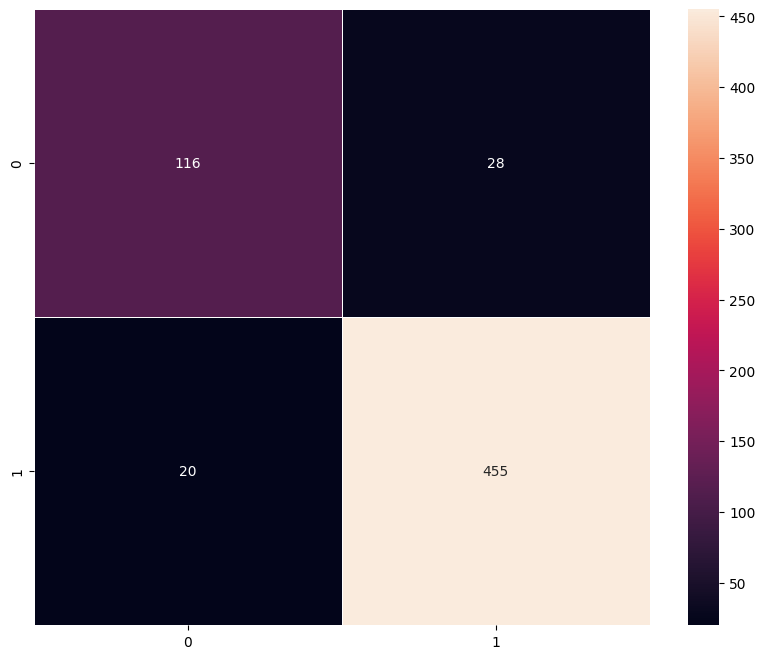

In [24]:
#plotting confusion matrix
plot_confusion_matrix(
    model,
    X_val,
    y_val
)

The model mostly classified the images correctly with small misclassifications

## Model 2: Transfer Learning with VGG-16 (Base)

In [25]:
#using weights of the vgg 16 model
vgg_model=VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
#summary of the model
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#freezing the layers of the vgg  model
for layer in vgg_model.layers:
  layer.trainable=False

In [27]:
#initializing the new model
model2=Sequential()
#adding the convolutional part of the vgg 16 model
model2.add(vgg_model)
#flattening the output of the vgg 16 model
model2.add(Flatten())
model2.add(Dense(1,activation='sigmoid'))


In [28]:
#compiling the model
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Visualizing the predictions

In [29]:
#fitting the model on the training data
history_2=model2.fit(X_train,y_train,epochs=15,batch_size=64,shuffle=True,validation_data=(X_val,y_val),verbose=2)

Epoch 1/15
46/46 - 22s - 475ms/step - accuracy: 0.8143 - loss: 0.4190 - val_accuracy: 0.8708 - val_loss: 0.3220
Epoch 2/15
46/46 - 15s - 337ms/step - accuracy: 0.8961 - loss: 0.2601 - val_accuracy: 0.8595 - val_loss: 0.3005
Epoch 3/15
46/46 - 15s - 325ms/step - accuracy: 0.9127 - loss: 0.2209 - val_accuracy: 0.8708 - val_loss: 0.2803
Epoch 4/15
46/46 - 15s - 323ms/step - accuracy: 0.9224 - loss: 0.1959 - val_accuracy: 0.8805 - val_loss: 0.2569
Epoch 5/15
46/46 - 15s - 326ms/step - accuracy: 0.9352 - loss: 0.1754 - val_accuracy: 0.8853 - val_loss: 0.2504
Epoch 6/15
46/46 - 15s - 329ms/step - accuracy: 0.9470 - loss: 0.1579 - val_accuracy: 0.8724 - val_loss: 0.2572
Epoch 7/15
46/46 - 15s - 327ms/step - accuracy: 0.9508 - loss: 0.1436 - val_accuracy: 0.8740 - val_loss: 0.2591
Epoch 8/15
46/46 - 15s - 328ms/step - accuracy: 0.9553 - loss: 0.1317 - val_accuracy: 0.8756 - val_loss: 0.2557
Epoch 9/15
46/46 - 15s - 323ms/step - accuracy: 0.9619 - loss: 0.1218 - val_accuracy: 0.8788 - val_loss:

MODEL EVALUATION

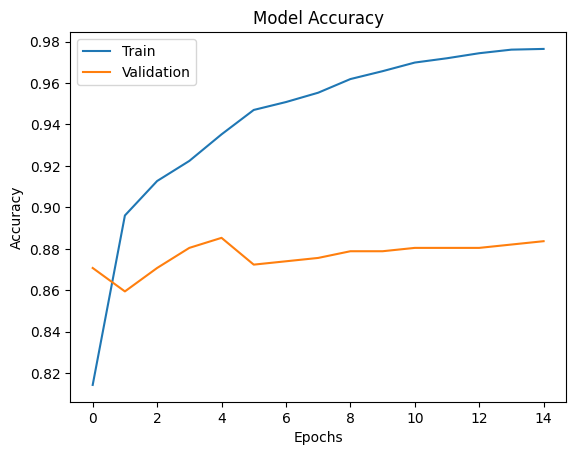

In [30]:
#plotting accuracy of training and validation set
plt.plot(history_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

The model is attaining a higher training accuracy but comparatively lower but stable validation accuracy indicatig noticeable overfitting

In [31]:
#checking the performance on the training data
vgg_train_perf = model_performance_classification(
    model2,
    X_train,
    y_train
)

print("Training Performance")
print(vgg_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step
Training Performance
   Accuracy    Recall  Precision  F1 Score
0  0.966401  0.966401   0.966401  0.966401


In [32]:
#checking the performance on the validation data
vgg_val_perf = model_performance_classification(
    model2,
    X_val,
    y_val
)

print("Validation Performance")
print(vgg_val_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step
Validation Performance
   Accuracy    Recall  Precision  F1 Score
0  0.883683  0.883683   0.883683  0.883683


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


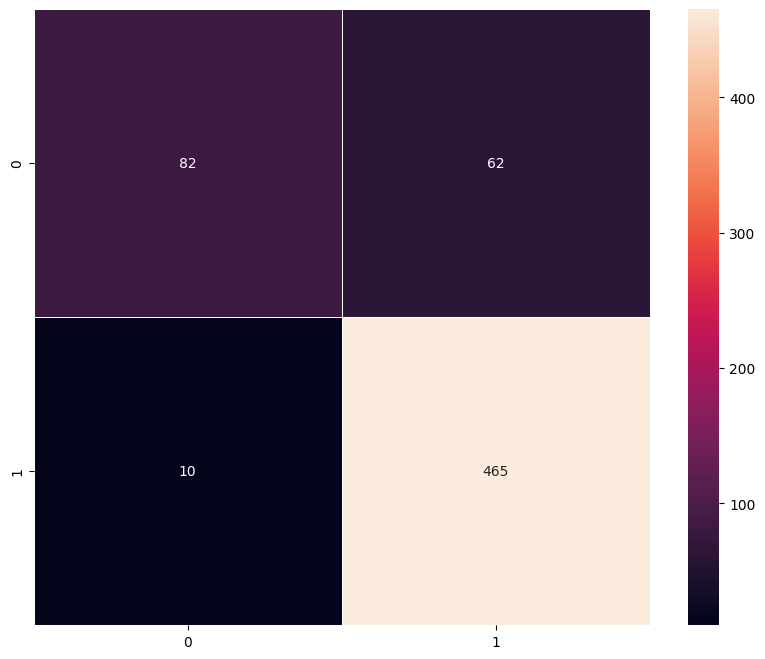

In [33]:
#plotting confusion matrix
plot_confusion_matrix(
    model2,
    X_val,
    y_val
)

The model shows relatively higher misclassification with "without helmet" class

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [34]:
model3 = Sequential()
#adding the convolutional part of the vgg 16 model
model3.add(vgg_model)
#flattening the output of the vgg 16  model
model3.add(Flatten())
#adding some dense layers
model3.add(Dense(32, activation='relu'))
#batch normalization
model3.add(BatchNormalization())
#dropout regularization
model3.add(Dropout(0.5))
model3.add(Dense(32, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))
#adding the output layer
model3.add(Dense(1, activation='sigmoid'))

In [37]:
#compiling the model
model3.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#### Visualizing the predictions

In [38]:
#fitting the model on the training data
history_3=model3.fit(X_train,y_train,epochs=15,batch_size=64,shuffle=True,validation_data=(X_val,y_val),verbose=2)

Epoch 1/15
46/46 - 21s - 458ms/step - accuracy: 0.6044 - loss: 0.7263 - val_accuracy: 0.6607 - val_loss: 0.6083
Epoch 2/15
46/46 - 17s - 363ms/step - accuracy: 0.7309 - loss: 0.5319 - val_accuracy: 0.8271 - val_loss: 0.3605
Epoch 3/15
46/46 - 15s - 335ms/step - accuracy: 0.8064 - loss: 0.4244 - val_accuracy: 0.8255 - val_loss: 0.4108
Epoch 4/15
46/46 - 15s - 334ms/step - accuracy: 0.8410 - loss: 0.3660 - val_accuracy: 0.8643 - val_loss: 0.3725
Epoch 5/15
46/46 - 15s - 319ms/step - accuracy: 0.8763 - loss: 0.3155 - val_accuracy: 0.8691 - val_loss: 0.2848
Epoch 6/15
46/46 - 15s - 331ms/step - accuracy: 0.9027 - loss: 0.2624 - val_accuracy: 0.8740 - val_loss: 0.2563
Epoch 7/15
46/46 - 15s - 334ms/step - accuracy: 0.9103 - loss: 0.2219 - val_accuracy: 0.8691 - val_loss: 0.2860
Epoch 8/15
46/46 - 15s - 335ms/step - accuracy: 0.9228 - loss: 0.2002 - val_accuracy: 0.8659 - val_loss: 0.3069
Epoch 9/15
46/46 - 15s - 330ms/step - accuracy: 0.9293 - loss: 0.1871 - val_accuracy: 0.8627 - val_loss:

MODEL EVALUATION

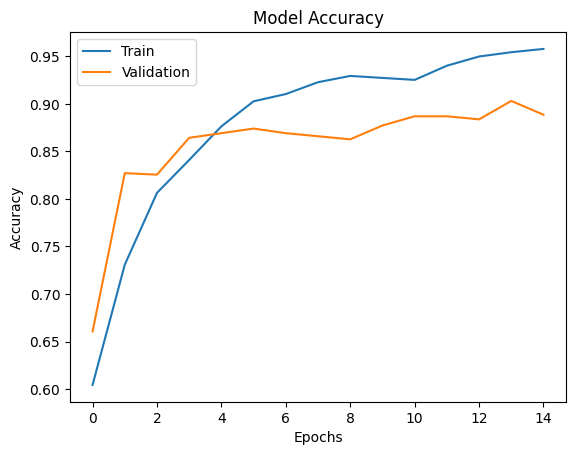

In [40]:
#plotting accuracy of training and validation set
plt.plot(history_3.history['accuracy'], label='Training Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [41]:
#checking the performance on the training data
vgg_ffn_train_perf = model_performance_classification(
    model3,
    X_train,
    y_train
)

print("Training Performance")
print(vgg_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step
Training Performance
   Accuracy    Recall  Precision  F1 Score
0  0.966401  0.966401   0.966401  0.966401


In [42]:
#checking the performance on the validation data
vgg_ffn_val_perf = model_performance_classification(
    model3,
    X_val,
    y_val
)

print("Validation Performance")
print(vgg_val_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step
Validation Performance
   Accuracy    Recall  Precision  F1 Score
0  0.883683  0.883683   0.883683  0.883683


The model showed good performance on training dataset and validation dataset but still moderate overfitting can be seen

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step


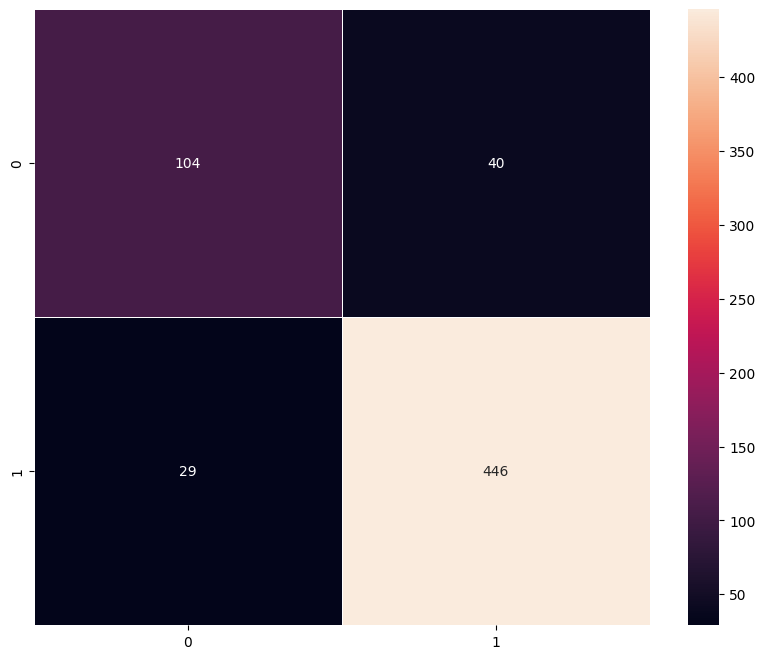

In [43]:
#plotting confusion matrix
plot_confusion_matrix(
    model3,
    X_val,
    y_val
)

This model reduced the misclassification of " without helmet" images compared to the previous model

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

In [44]:
#creating data augmentation generator
train_datagen = ImageDataGenerator(horizontal_flip=True,
vertical_flip=False,
width_shift_range=0.2,
height_shift_range=0.2,
rotation_range=20,
shear_range=0.2,
zoom_range=0.2
)

In [45]:
#fitting generator on training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=64)


In [46]:
model4 = Sequential()
#adding the convolutional part of the vgg 16 model
model4.add(vgg_model)
#flattening the output of the vgg 16  model
model4.add(Flatten())
#adding some dense layers
model4.add(Dense(32, activation='relu'))
#batch normalization
model4.add(BatchNormalization())
#dropout regularization
model4.add(Dropout(0.5))
model4.add(Dense(32, activation='relu'))
model4.add(BatchNormalization())
model4.add(Dropout(0.5))
#adding the output layer
model4.add(Dense(1, activation='sigmoid'))

In [47]:
#compiling the model
model4.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#### Visualizing the predictions

In [48]:
#fitting the model on the training data
history_4=model4.fit(train_generator,
validation_data=(X_val, y_val),
epochs=15,
verbose=2
)

Epoch 1/15
46/46 - 45s - 971ms/step - accuracy: 0.5992 - loss: 0.8083 - val_accuracy: 0.2391 - val_loss: 3.6395
Epoch 2/15
46/46 - 41s - 887ms/step - accuracy: 0.6772 - loss: 0.6472 - val_accuracy: 0.2746 - val_loss: 2.6811
Epoch 3/15
46/46 - 41s - 883ms/step - accuracy: 0.7208 - loss: 0.5708 - val_accuracy: 0.4459 - val_loss: 1.3230
Epoch 4/15
46/46 - 41s - 884ms/step - accuracy: 0.7766 - loss: 0.5052 - val_accuracy: 0.8611 - val_loss: 0.3440
Epoch 5/15
46/46 - 39s - 851ms/step - accuracy: 0.7759 - loss: 0.4758 - val_accuracy: 0.8595 - val_loss: 0.3053
Epoch 6/15
46/46 - 39s - 842ms/step - accuracy: 0.8081 - loss: 0.4237 - val_accuracy: 0.8578 - val_loss: 0.3239
Epoch 7/15
46/46 - 41s - 880ms/step - accuracy: 0.8306 - loss: 0.3958 - val_accuracy: 0.8417 - val_loss: 0.3583
Epoch 8/15
46/46 - 41s - 882ms/step - accuracy: 0.8247 - loss: 0.3948 - val_accuracy: 0.8433 - val_loss: 0.3564
Epoch 9/15
46/46 - 41s - 882ms/step - accuracy: 0.8296 - loss: 0.3823 - val_accuracy: 0.8659 - val_loss:

MODEL EVALUATION

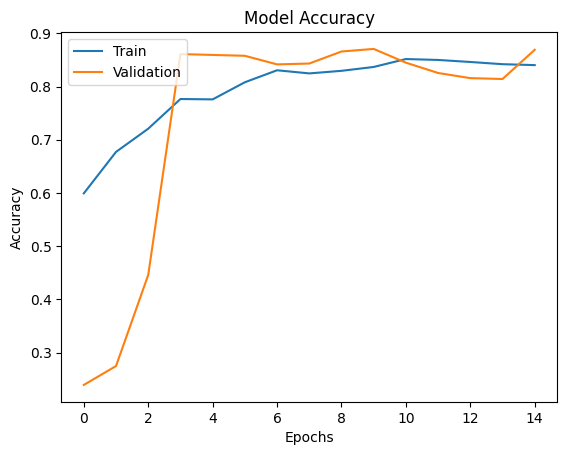

In [49]:
#plotting accuracy of training and validation set
plt.plot(history_4.history['accuracy'], label='Training Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


The model showed increased validation accuracy compared to previous model,indicating reduced overfitting

In [51]:
#checking the performance on the training data
vgg_aug_ffn_train_perf = model_performance_classification(
    model4,
    X_train,
    y_train
)

print("Training Performance")
print(vgg_aug_ffn_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step
Training Performance
   Accuracy    Recall  Precision  F1 Score
0  0.892622  0.892622   0.892622  0.892622


In [53]:
vgg_aug_ffn_val_perf = model_performance_classification(
    model3,
    X_val,
    y_val
)

print("Validation Performance")
print(vgg_aug_ffn_val_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step
Validation Performance
   Accuracy   Recall  Precision  F1 Score
0   0.88853  0.88853    0.88853   0.88853


The model showed comparable performance on training and the testing data,with least overfitting

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step


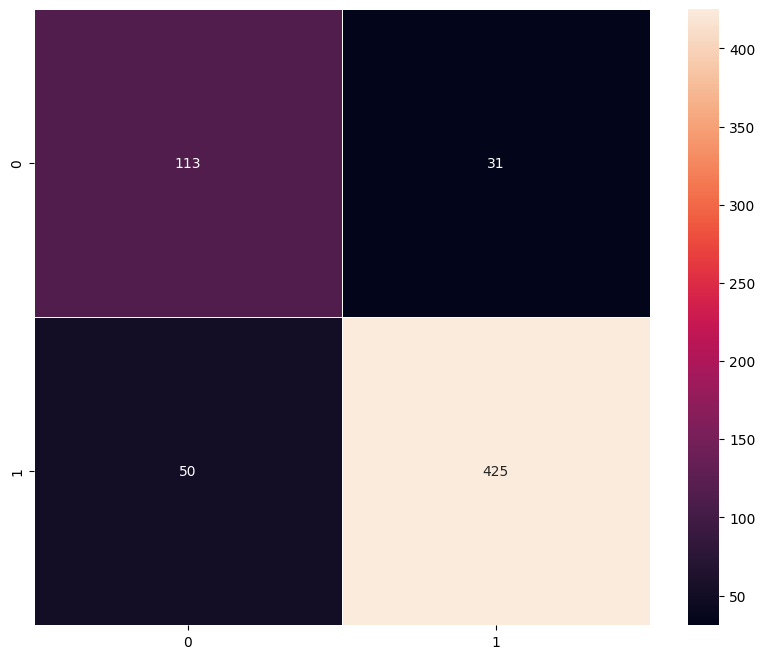

In [54]:
#plotting confusion matrix
plot_confusion_matrix(
    model4,
    X_val,
    y_val
)

# **Model Performance Comparison and Final Model Selection**

In [56]:
#Training performance comparison
models_train_comp_df=pd.concat([
    cnn_train_perf.T,
    vgg_train_perf.T,
    vgg_ffn_train_perf.T,
    vgg_aug_ffn_train_perf.T
    ],
    axis=1,
)

models_train_comp_df.columns=["CNN","VGG_Base","VGG_Base_FFN","VGG_Base_FFN_Aug"]

In [57]:
models_train_comp_df

,CNN,VGG_Base,VGG_Base_FFN,VGG_Base_FFN_Aug
Accuracy,0.981988,0.966401,0.985106,0.892622
Recall,0.981988,0.966401,0.985106,0.892622
Precision,0.981988,0.966401,0.985106,0.892622
F1 Score,0.981988,0.966401,0.985106,0.892622


In [58]:
#validation performance comparison
models_val_comp_df=pd.concat([
    cnn_val_perf.T,
    vgg_val_perf.T,
    vgg_ffn_val_perf.T,
    vgg_aug_ffn_val_perf.T
    ],
    axis=1,
)

models_val_comp_df.columns=["CNN","VGG_Base","VGG_Base_FFN","VGG_Base_FFN_Aug"]

In [59]:
models_val_comp_df

,CNN,VGG_Base,VGG_Base_FFN,VGG_Base_FFN_Aug
Accuracy,0.922456,0.883683,0.88853,0.88853
Recall,0.922456,0.883683,0.88853,0.88853
Precision,0.922456,0.883683,0.88853,0.88853
F1 Score,0.922456,0.883683,0.88853,0.88853


The CNN model from scratch achieved highest validation accuracy ~92% indicating better  generalization on unseen data

The transfer learning models using VGG16 achieved very high training performance but comparatively lower validation performance, suggesting overfitting to the training dataset.

Adding FFNN layers and data augmentation slightly achieved improved performance than basic vgg 16 model

So,i will go with the CNN model from scratch

## Test Performance

In [60]:
#checking test performance
cnn_test_perf = model_performance_classification(
    model,
    X_test,
    y_test
)
print("Test Performance")
print(cnn_test_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Test Performance
   Accuracy    Recall  Precision  F1 Score
0  0.914378  0.914378   0.914378  0.914378


The model has achieved a strong performance on the unseen data with ~91% accuracy which inidicates good generalizing capability and effective classification

# **Actionable Insights & Recommendations**

The CNN model from scratch achieved the best overall performance with approximately 91% test accuracy, indicating strong generalization capability on unseen data.


The dataset showed class imbalance, with “With Helmet” images significantly outnumbering “Without Helmet” images, which may affect minority class prediction performance.

Transfer learning models based on VGG16 achieved high training accuracy but exhibited comparatively lower validation accuracy, indicating overfitting.

Deploy the CNN-based helmet detection system in traffic surveillance and industrial safety monitoring applications to automate helmet compliance checking.

Increase the number of “Without Helmet” images to reduce class imbalance and improve model performance on minority class detection.



<font size=5 color='blue'>Power Ahead!</font>
___